# ベクトル化完全ガイド

> データをコンピュータが処理できる数値表現に変換するプロセスの全体像

---

## 📋 目次

1. ベクトル化とは
2. 数学的基礎
3. NLPでのベクトル化
4. 実装パターン
5. 応用と活用
6. ベストプラクティス

## 1. ベクトル化とは

### 定義

**ベクトル化**とは、非数値データ（テキスト、画像、カテゴリなど）を数値ベクトル（数字の配列）に変換するプロセスです。

In [1]:
# ベクトル化の例
import numpy as np

# テキスト → ベクトル
text = "hello world"
embedding_vector = np.array([0.2, -0.5, 0.8, 0.1])  # 埋め込みベクトル

print(f"テキスト: {repr(text)}")
print(f"ベクトル: {embedding_vector}")
print(f"ベクトル次元: {len(embedding_vector)}")

テキスト: 'hello world'
ベクトル: [ 0.2 -0.5  0.8  0.1]
ベクトル次元: 4


### なぜベクトル化が必要か？

- **機械学習モデル**: ニューラルネットワークは数値入力を要求
- **類似度計算**: ベクトル間の距離で意味的類似性を測定
- **次元削減**: 高次元データから特徴を抽出
- **計算効率**: 数値演算はテキスト操作より高速

## 2. 数学的基礎

### ベクトル空間の概念

#### 1次元ベクトル
```
v = [5]
```
数直線上の単一の点

#### 2次元ベクトル
```
v = [3, 4]
```

#### N次元ベクトル
```
v = [v₁, v₂, v₃, ..., vₙ]
```

例：テキスト埋め込みベクトル（768次元）

/home/abemc/project_root/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/abemc/project_root/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/abemc/project_root/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12505 (\N{KATAKANA LETTER BE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/abemc/project_root/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/abemc/project_root/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 1

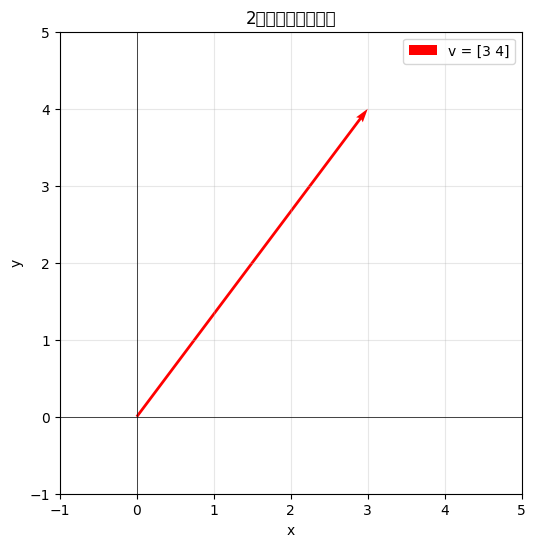

ベクトル v = [3 4]
L2ノルム（ユークリッド）: 5.0
L1ノルム（マンハッタン）: 7


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 2次元ベクトルのビジュアライゼーション
fig, ax = plt.subplots(figsize=(8, 6))

# ベクトル
v = np.array([3, 4])

# プロット
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.006, label=f'v = {v}')
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('2次元ベクトル表現')
ax.legend()
plt.show()

# ノルムの計算
norm_l2 = np.linalg.norm(v)  # L2ノルム
norm_l1 = np.sum(np.abs(v))  # L1ノルム

print(f"ベクトル v = {v}")
print(f"L2ノルム（ユークリッド）: {norm_l2}")
print(f"L1ノルム（マンハッタン）: {norm_l1}")

### 重要な操作

#### 正規化（Normalization）

ベクトルの大きさを1に統一する操作：
$$\hat{v} = \frac{v}{||v||_2}$$

In [3]:
# ベクトルの正規化
v = np.array([3, 4])

# L2ノルムで正規化
v_normalized = v / np.linalg.norm(v)

print(f"元のベクトル: {v}")
print(f"正規化ベクトル: {v_normalized}")
print(f"正規化後のノルム: {np.linalg.norm(v_normalized)}")  # 1.0になる

元のベクトル: [3 4]
正規化ベクトル: [0.6 0.8]
正規化後のノルム: 1.0


#### コサイン類似度

2つのベクトル間の角度を用いた類似度尺度：
$$\cos(\theta) = \frac{v_1 \cdot v_2}{||v_1|| \cdot ||v_2||}$$

- 値域：-1～1
- 1：同一方向（完全に類似）
- 0：直交（無関係）
- -1：反対方向（完全に異なる）

In [4]:
# コサイン類似度の計算
v1 = np.array([1, 0, 0])
v2 = np.array([1, 1, 0])
v3 = np.array([-1, 0, 0])  # v1と反対方向

def cosine_similarity(v1, v2):
    """コサイン類似度を計算"""
    dot_product = np.dot(v1, v2)
    norms = np.linalg.norm(v1) * np.linalg.norm(v2)
    return dot_product / norms

sim_v1_v2 = cosine_similarity(v1, v2)
sim_v1_v3 = cosine_similarity(v1, v3)

print(f"v1 = {v1}")
print(f"v2 = {v2}")
print(f"v3 = {v3}")
print(f"\nv1とv2のコサイン類似度: {sim_v1_v2:.3f}")
print(f"v1とv3のコサイン類似度: {sim_v1_v3:.3f}")

v1 = [1 0 0]
v2 = [1 1 0]
v3 = [-1  0  0]

v1とv2のコサイン類似度: 0.707
v1とv3のコサイン類似度: -1.000


## 3. NLPでのベクトル化手法

### 3.1 One-Hot Encoding

最もシンプルな方法。語彙内の単語を一意にエンコード。

In [5]:
# One-Hot Encoding
class OneHotEncoder:
    def __init__(self, vocab):
        self.word2id = {word: idx for idx, word in enumerate(vocab)}
        self.vocab_size = len(vocab)
    
    def encode(self, word):
        vec = np.zeros(self.vocab_size)
        if word in self.word2id:
            vec[self.word2id[word]] = 1
        return vec

encoder = OneHotEncoder(["cat", "dog", "bird"])

print("One-Hot Encoding例:")
print(f"'cat'  → {encoder.encode('cat')}")
print(f"'dog'  → {encoder.encode('dog')}")
print(f"'bird' → {encoder.encode('bird')}")

One-Hot Encoding例:
'cat'  → [1. 0. 0.]
'dog'  → [0. 1. 0.]
'bird' → [0. 0. 1.]


### 3.2 Bag-of-Words (BoW)

テキスト全体の単語の出現頻度を集計。

In [6]:
from collections import Counter

def bag_of_words(text, vocab):
    """テキストをBoWベクトルに変換"""
    tokens = text.lower().split()
    word_counts = Counter(tokens)
    
    vec = np.zeros(len(vocab))
    for word, count in word_counts.items():
        if word in vocab:
            idx = vocab.index(word)
            vec[idx] = count
    return vec

vocab = ["i", "love", "cats", "dogs"]
text = "i love cats i love dogs"
bow = bag_of_words(text, vocab)

print(f"テキスト: {repr(text)}")
print(f"語彙: {vocab}")
print(f"BoWベクトル: {bow}")
print(f"解釈: i({int(bow[0])}回), love({int(bow[1])}回), cats({int(bow[2])}回), dogs({int(bow[3])}回))")

テキスト: 'i love cats i love dogs'
語彙: ['i', 'love', 'cats', 'dogs']
BoWベクトル: [2. 2. 1. 1.]
解釈: i(2回), love(2回), cats(1回), dogs(1回))


### 3.3 TF-IDF（Term Frequency-Inverse Document Frequency）

単語の重要度を考慮した特徴抽出。

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

documents = [
    "python is great",
    "python programming is fun",
    "machine learning is important"
]

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(documents)

# 結果を見やすく表示
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

print("TF-IDF行列:")
print(df_tfidf.round(3))
print(f"\n形状: {tfidf_matrix.shape}")  # ドキュメント数 × 語彙サイズ

TF-IDF行列:
     fun  great  important     is  learning  machine  programming  python
0  0.000   0.72      0.000  0.425     0.000    0.000        0.000   0.548
1  0.584   0.00      0.000  0.345     0.000    0.000        0.584   0.445
2  0.000   0.00      0.546  0.323     0.546    0.546        0.000   0.000

形状: (3, 8)


### 3.4 Word Embeddings (Word2Vec)

文脈を学習した密集ベクトル。

In [8]:
# Word2Vecの簡易実装例（Gensimを使用）
try:
    from gensim.models import Word2Vec
    
    sentences = [
        ["the", "quick", "brown", "fox"],
        ["jumps", "over", "the", "lazy", "dog"],
        ["machine", "learning", "is", "important"]
    ]
    
    # モデルの訓練
    model = Word2Vec(sentences, vector_size=50, window=2, min_count=1, sg=1)
    
    # 単語の埋め込みベクトル取得
    vec_quick = model.wv['quick']
    
    print(f"'quick'の埋め込みベクトル（最初の5次元）: {vec_quick[:5]}")
    print(f"ベクトル次元: {len(vec_quick)}")
    
    # 類似単語検索
    similar = model.wv.most_similar('quick', topn=2)
    print(f"\n'quick'に類似した単語:")
    for word, score in similar:
        print(f"  {word}: {score:.3f}")

except ImportError:
    print("Gensimがインストールされていません。")
    print("インストール: pip install gensim")

Gensimがインストールされていません。
インストール: pip install gensim


### 3.5 BERT/Transformer埋め込み

文脈に応じた動的な埋め込み。同じ単語でも文脈に応じて異なるベクトルを出力。

In [9]:
# BERT埋め込みの例
try:
    from transformers import AutoTokenizer, AutoModel
    import torch
    
    model_name = "bert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    
    text = "I love natural language processing"
    
    # トークン化
    tokens = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    
    # 埋め込み取得
    with torch.no_grad():
        outputs = model(**tokens)
    
    embeddings = outputs.last_hidden_state  # [1, num_tokens, 768]
    
    print(f"テキスト: {repr(text)}")
    print(f"埋め込み形状: {embeddings.shape}")  # [batch, seq_len, hidden_dim]
    print(f"隠れ層次元：{embeddings.shape[-1]}")
    
    # 文章埋め込み（Mean Pooling）
    sentence_embedding = embeddings.mean(dim=1)
    print(f"\n文章埋め込み形状: {sentence_embedding.shape}")  # [1, 768]

except ImportError:
    print("Transformersがインストールされていません。")
    print("インストール: pip install transformers torch")
except Exception as e:
    print(f"エラー: {e}")
    print("モデルのダウンロードが必要な場合があります。")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


テキスト: 'I love natural language processing'
埋め込み形状: torch.Size([1, 7, 768])
隠れ層次元：768

文章埋め込み形状: torch.Size([1, 768])


## 4. 実装パターン

### パターン1: テキスト → 埋め込み → 類似度計算

In [10]:
class SimpleTextVectorizer:
    """簡易的なテキストベクトライザー"""
    
    def __init__(self, vocab):
        self.vocab = vocab
        self.dim = len(vocab)
    
    def vectorize(self, text):
        """テキストを BoW ベクトルに変換"""
        tokens = text.lower().split()
        vec = np.zeros(self.dim)
        for token in tokens:
            if token in self.vocab:
                idx = self.vocab.index(token)
                vec[idx] += 1
        return vec
    
    def similarity(self, text1, text2):
        """2つのテキスト間の類似度を計算"""
        vec1 = self.vectorize(text1)
        vec2 = self.vectorize(text2)
        
        # コサイン類似度
        dot = np.dot(vec1, vec2)
        norm = np.linalg.norm(vec1) * np.linalg.norm(vec2)
        return dot / (norm + 1e-10)  # ゼロ除算を避ける

# 使用例
vocab = ["machine", "learning", "is", "fun", "important", "deep"]
vectorizer = SimpleTextVectorizer(vocab)

text1 = "machine learning is fun"
text2 = "deep learning is important"
text3 = "cats are cute"

print(f"テキスト1: '{text1}'")
print(f"テキスト2: '{text2}'")
print(f"テキスト3: '{text3}'")
print(f"\ntext1 vs text2 の類似度: {vectorizer.similarity(text1, text2):.3f}")
print(f"text1 vs text3 の類似度: {vectorizer.similarity(text1, text3):.3f}")

テキスト1: 'machine learning is fun'
テキスト2: 'deep learning is important'
テキスト3: 'cats are cute'

text1 vs text2 の類似度: 0.500
text1 vs text3 の類似度: 0.000


### パターン2: カテゴリデータのベクトル化

In [11]:
class CategoricalVectorizer:
    """カテゴリデータを数値ベクトルに変換"""
    
    def __init__(self, categories):
        self.categories = categories
        self.category2id = {cat: idx for idx, cat in enumerate(categories)}
    
    def one_hot(self, category):
        """One-Hot encoding"""
        vec = np.zeros(len(self.categories))
        if category in self.category2id:
            vec[self.category2id[category]] = 1
        return vec
    
    def label_encoding(self, category):
        """ラベルエンコーディング"""
        return self.category2id.get(category, -1)

# 使用例
vectorizer = CategoricalVectorizer(['cat', 'dog', 'bird'])

print("One-Hot Encoding:")
print(f"'cat':  {vectorizer.one_hot('cat')}")
print(f"'dog':  {vectorizer.one_hot('dog')}")
print(f"'bird': {vectorizer.one_hot('bird')}")

print("\nLabel Encoding:")
print(f"'cat':  {vectorizer.label_encoding('cat')}")
print(f"'dog':  {vectorizer.label_encoding('dog')}")
print(f"'bird': {vectorizer.label_encoding('bird')}")

One-Hot Encoding:
'cat':  [1. 0. 0.]
'dog':  [0. 1. 0.]
'bird': [0. 0. 1.]

Label Encoding:
'cat':  0
'dog':  1
'bird': 2


### パターン3: 数値データの正規化

In [12]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# データ
data = np.array([
    [1, 100],
    [2, 200],
    [3, 300],
    [4, 400]
])

# 標準化（Z-score正規化）
scaler_standard = StandardScaler()
data_standard = scaler_standard.fit_transform(data)

# 正規化（Min-Max正規化）
scaler_minmax = MinMaxScaler()
data_minmax = scaler_minmax.fit_transform(data)

print("元のデータ:")
print(data)

print("\n標準化後（平均0、分散1）:")
print(data_standard.round(3))

print("\n正規化後（0-1範囲）:")
print(data_minmax.round(3))

元のデータ:
[[  1 100]
 [  2 200]
 [  3 300]
 [  4 400]]

標準化後（平均0、分散1）:
[[-1.342 -1.342]
 [-0.447 -0.447]
 [ 0.447  0.447]
 [ 1.342  1.342]]

正規化後（0-1範囲）:
[[0.    0.   ]
 [0.333 0.333]
 [0.667 0.667]
 [1.    1.   ]]


## 5. 応用と活用

### 5.1 テキスト分類（シミュレーション）

In [13]:
# テキスト分類の簡易例
class SimpleTextClassifier:
    """ベクトルベースの簡易分類器"""
    
    def __init__(self, vocab):
        self.vocab = vocab
        self.class_centers = {}
    
    def vectorize(self, text):
        tokens = text.lower().split()
        vec = np.zeros(len(self.vocab))
        for token in tokens:
            if token in self.vocab:
                idx = self.vocab.index(token)
                vec[idx] += 1
        return vec
    
    def classify(self, text):
        """テキストをクラス分類"""
        text_vec = self.vectorize(text)
        
        # 各クラスとの類似度を計算
        similarities = {}
        for label, center in self.class_centers.items():
            dot = np.dot(text_vec, center)
            norm = np.linalg.norm(text_vec) * np.linalg.norm(center)
            similarities[label] = dot / (norm + 1e-10)
        
        # 最も類似度が高いクラスを返す
        return max(similarities, key=similarities.get)

# 例
vocab = ["good", "bad", "great", "terrible", "excellent", "awful"]
classifier = SimpleTextClassifier(vocab)

# クラスの中心を定義（訓練データから計算することを想定）
classifier.class_centers['positive'] = np.array([1, 0, 1, 0, 1, 0])
classifier.class_centers['negative'] = np.array([0, 1, 0, 1, 0, 1])

test_texts = ["good great", "bad terrible", "excellent awful"]
for text in test_texts:
    pred = classifier.classify(text)
    print(f"'{text}' → {pred}")

'good great' → positive
'bad terrible' → negative
'excellent awful' → positive


### 5.2 類似文検索

In [14]:
class DocumentSearcher:
    """ベクトル空間でのドキュメント検索"""
    
    def __init__(self, vocab):
        self.vocab = vocab
        self.documents = []
        self.vectors = []
    
    def add_document(self, doc_id, text):
        """ドキュメントを追加"""
        tokens = text.lower().split()
        vec = np.zeros(len(self.vocab))
        for token in tokens:
            if token in self.vocab:
                idx = self.vocab.index(token)
                vec[idx] += 1
        
        self.documents.append((doc_id, text))
        self.vectors.append(vec)
    
    def search(self, query, top_k=3):
        """類似ドキュメントを検索"""
        tokens = query.lower().split()
        query_vec = np.zeros(len(self.vocab))
        for token in tokens:
            if token in self.vocab:
                idx = self.vocab.index(token)
                query_vec[idx] += 1
        
        # すべてのドキュメントとの類似度を計算
        similarities = []
        for doc_id, text in self.documents:
            vec = self.vectors[self.documents.index((doc_id, text))]
            dot = np.dot(query_vec, vec)
            norm = np.linalg.norm(query_vec) * np.linalg.norm(vec)
            sim = dot / (norm + 1e-10)
            similarities.append((doc_id, text, sim))
        
        # 類似度でソート
        return sorted(similarities, key=lambda x: x[2], reverse=True)[:top_k]

# 例
vocab = ["machine", "learning", "deep", "artificial", "intelligence", "neural", "network"]
searcher = DocumentSearcher(vocab)

# ドキュメントを追加
searcher.add_document('doc1', 'machine learning deep neural network')
searcher.add_document('doc2', 'artificial intelligence machine learning')
searcher.add_document('doc3', 'deep neural network learning')
searcher.add_document('doc4', 'the weather is sunny')

# 検索
query = 'machine learning'
results = searcher.search(query, top_k=3)

print(f"クエリ: '{query}'\n")
for doc_id, text, sim in results:
    print(f"{doc_id}: '{text}' (類似度: {sim:.3f})")

クエリ: 'machine learning'

doc2: 'artificial intelligence machine learning' (類似度: 0.707)
doc1: 'machine learning deep neural network' (類似度: 0.632)
doc3: 'deep neural network learning' (類似度: 0.354)


## 6. ベストプラクティス

### チェックリスト

In [15]:
def validate_embeddings(embeddings):
    """埋め込みベクトルの検証"""
    print("埋め込みベクト検証:")
    print()
    
    # 形状確認
    print(f"✓ 形状: {embeddings.shape}")
    
    # 値域チェック
    has_nan = np.isnan(embeddings).any()
    has_inf = np.isinf(embeddings).any()
    print(f"✓ NaN: {'なし' if not has_nan else 'あり⚠️'}")
    print(f"✓ Inf: {'なし' if not has_inf else 'あり⚠️'}")
    
    # ノルムチェック
    norms = np.linalg.norm(embeddings, axis=1)
    print(f"✓ ノルム統計: 平均={norms.mean():.3f}, 最小={norms.min():.3f}, 最大={norms.max():.3f}")
    
    # 類似度値域（サンプル）
    if len(embeddings) >= 2:
        sample_sim = np.dot(embeddings[0], embeddings[1]) / (norms[0] * norms[1] + 1e-10)
        print(f"✓ サンプル類似度: {sample_sim:.3f} (値域: -1～1)")
    
    print(f"\n✅ 検証完了")

# 検証例
embeddings = np.random.randn(10, 768)  # 10個の768次元ベクトル
validate_embeddings(embeddings)

埋め込みベクト検証:

✓ 形状: (10, 768)
✓ NaN: なし
✓ Inf: なし
✓ ノルム統計: 平均=27.499, 最小=26.309, 最大=29.574
✓ サンプル類似度: 0.028 (値域: -1～1)

✅ 検証完了


### 推奨事項まとめ

1. **前処理の統一**: 訓練・テストで同じ正規化方法を使用
2. **次元の選択**:
   - One-Hot: 語彙サイズ（高次元、スパース）
   - 埋め込み: 100-768次元（密集）
3. **パフォーマンストレードオフ**:
   ```
   精度 ↑         計算速度 ↑
   OneHot → TF-IDF → Word2Vec → BERT
   ```
4. **言語別の推奨**:
   - 英語: Word2Vec, GloVe, BERT
   - 日本語: BERT (japanese版), Fasttext
   - 多言語: mBERT, XLM-R
5. **ハイパーパラメータ**:
   - 埋め込み次元: 64-768
   - ウィンドウサイズ: 5-10
   - min_count（出現頻度フィルタ）: 1-5

## まとめ

ベクトル化は機械学習の基礎となるプロセスです。

- **初心者**: One-Hot, Bag-of-Words から始める
- **中級者**: TF-IDF, Word2Vec で効率化
- **上級者**: BERT/Transformer で高精度実現

各手法の長所と短所を理解し、タスク・データ・計算環境に応じて適切に選択することが重要です。👍